In [1]:
# Enable Float64 for more stable matrix inversions.
from jax import config
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import install_import_hook
import matplotlib as mpl
import matplotlib.pyplot as plt
import optax as ox

config.update("jax_enable_x64", True)


with install_import_hook("gpjax", "beartype.beartype"):
    import gpjax as gpx
    import gpjax.kernels as jk
    from gpjax.parameters import Parameter

key = jr.key(123)

cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

/dolfinx-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np



In [3]:
n = 50000
noise = 0.2

key, subkey = jr.split(key)
x = jr.uniform(key=key, minval=-5.0, maxval=5.0, shape=(n,)).reshape(-1, 1)
f = lambda x: 2 * (jnp.sin(4 * x) + jnp.cos(2 * x))
signal = f(x)
y = signal + jr.normal(subkey, shape=signal.shape) * noise
D = gpx.Dataset(X=x, y=y)

xtest = jnp.linspace(-5.5, 5.5, 500).reshape(-1, 1)

In [5]:
# x = np.arange(len(signal))
p = np.polyfit(x[:, 0], y, deg=2)  # 2 = quadratic trend
trend = np.polyval(p, x)
detrended = y - trend

In [6]:
D = gpx.Dataset(X=x, y=detrended)

In [7]:
y.shape

(50000, 1)

In [8]:
trend.shape

(50000, 1)

In [7]:
detrended_function = signal - trend[:, None]

In [ ]:
detrended.shape

(50000, 1)

: 

In [8]:
z = jnp.linspace(-5.0, 5.0, 50).reshape(-1, 1)

: 

[Text(0.5, 0, '$x$'), Text(0, 0.5, '$f(x)$')]

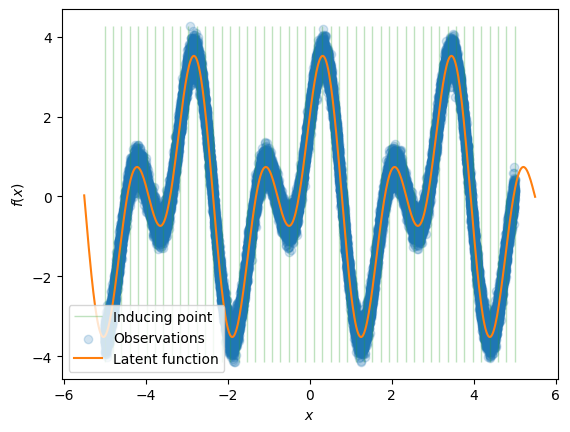

In [5]:
z = jnp.linspace(-5.0, 5.0, 50).reshape(-1, 1)

fig, ax = plt.subplots()
ax.vlines(
    z,
    ymin=y.min(),
    ymax=y.max(),
    alpha=0.3,
    linewidth=1,
    label="Inducing point",
    color=cols[2],
)
ax.scatter(x, y, alpha=0.2, color=cols[0], label="Observations")
ax.plot(xtest, f(xtest), color=cols[1], label="Latent function")
ax.legend()
ax.set(xlabel=r"$x$", ylabel=r"$f(x)$")

In [6]:
meanf = gpx.mean_functions.Zero()
likelihood = gpx.likelihoods.Gaussian(num_datapoints=n, obs_stddev=1.0)
kernel = jk.RBF()# 1-dimensional inputs
prior = gpx.gps.Prior(mean_function=meanf, kernel=kernel)
p = prior * likelihood
q = gpx.variational_families.VariationalGaussian(posterior=p, inducing_inputs=z)

In [7]:
schedule = ox.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=0.02,
    warmup_steps=75,
    decay_steps=2000,
    end_value=0.001,
)

opt_posterior, history = gpx.fit(
    model=q,
    # we are minimizing the elbo so we negate it
    objective=lambda p, d: -gpx.objectives.elbo(p, d),
    train_data=D,
    optim=ox.adam(learning_rate=schedule),
    num_iters=50000,
    key=jr.key(42),
    batch_size=64,
    trainable=Parameter,
)

Running: 100%|██████████| 50000/50000 [00:45<00:00, 1109.72it/s, Value=-11043.50]


In [ ]:
fig, ax = plt.subplots()
ax.plot(history, color=cols[1])
ax.set_yscale("log")
ax.set(xlabel="Training iterate", ylabel="ELBO")

In [ ]:
xtest

In [ ]:
xtest.shape

In [ ]:
meanf.shape

In [ ]:
latent_dist = opt_posterior(xtest)
predictive_dist = opt_posterior.posterior.likelihood(latent_dist)

meanf = predictive_dist.mean
sigma = jnp.sqrt(predictive_dist.variance)

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.15, label="Training Data", color=cols[0])
ax.plot(xtest, meanf  + 2 * xtest[:, 0], label="Posterior mean", color=cols[1])
ax.fill_between(
    xtest.flatten(),
    meanf + 2 * xtest[:, 0] - 2 * sigma,
    meanf + 2 * xtest[:, 0] + 2 * sigma,
    alpha=0.3,
    color=cols[1],
    label="Two sigma",
)
ax.vlines(
    opt_posterior.inducing_inputs.value,
    ymin=y.min(),
    ymax=y.max(),
    alpha=0.3,
    linewidth=1,
    label="Inducing point",
    color=cols[2],
)
ax.legend()

In [3]:
from core.datasetclass import BenchmarkDataset
import jax.numpy as jnp

In [4]:

dataset = BenchmarkDataset("dataset/benchmarks", "noise=low", "Isihara")
loadsteps = [10, 20, 30, 40, 50, 60, 70, 80]
F_list = []
invariants_list = []
sigma_list = []
coeffs_list = []
for i in loadsteps :
    data = dataset[i]
    f = data["F"]
    invariants = data["invariants"]
    sigma = data["sigma"]
    coeffs = data["coeffs"]
    F_list.append(f)
    invariants_list.append(invariants)
    coeffs_list.append(coeffs)
    sigma_list.append(sigma)
F_train = jnp.concat(F_list)
invariants_train = jnp.concat(invariants_list)
sigma_train = jnp.concat(sigma_list)
coeffs_train = jnp.concat(coeffs_list)

In [7]:
coeffs_train

Array([[-4.14247960e-01,  7.89804280e-01,  3.47234891e-06],
       [-4.12711173e-01,  7.89329529e-01,  2.26885231e-06],
       [-4.14332300e-01,  7.89827406e-01,  2.88624506e-06],
       ...,
       [ 3.73050737e+00,  2.31665611e-01, -8.28782504e-07],
       [ 3.88775826e+00,  2.23970175e-01,  1.02061215e-07],
       [ 3.87605357e+00,  2.24282309e-01, -1.12500152e-06]],      dtype=float32)

In [35]:
import jax.numpy as jnp

# shape (N,)
x = invariants_train[:, 0]
y = invariants_train[:, 1]
z = invariants_train[:, 2]
c = coeffs_train[:, 0]   # continuous color values


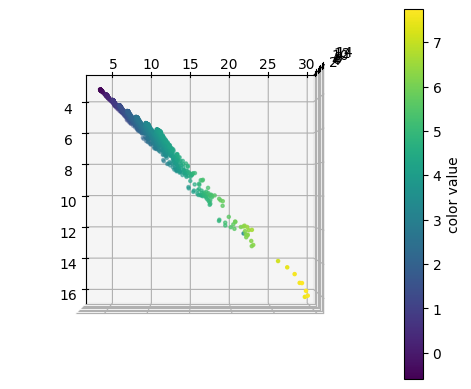

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x_np = np.array(x)
y_np = np.array(y)
z_np = np.array(z)
c_np = np.array(c)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 🔵 Change viewing angle here
ax.view_init(elev=90, azim=0)   # try different values

p = ax.scatter(x_np, y_np, z_np, c=c_np, cmap='viridis', s=5)
fig.colorbar(p, label="color value")
plt.show()


In [24]:
z0 = 3   # example
tol = 1e-1  # thickness of slice


In [25]:
mask = jnp.abs(z - z0) < tol
x_slice = np.array(x[mask])
y_slice = np.array(y[mask])
c_slice = np.array(c[mask])


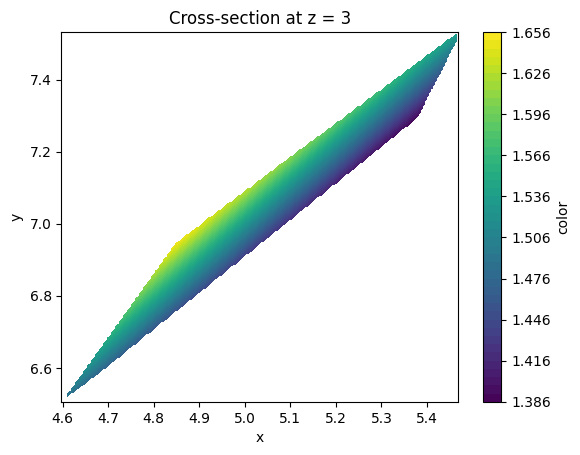

In [26]:
from scipy.interpolate import griddata

# build regular grid
xi = np.linspace(x_slice.min(), x_slice.max(), 200)
yi = np.linspace(y_slice.min(), y_slice.max(), 200)
X, Y = np.meshgrid(xi, yi)

# interpolate
C = griddata((x_slice, y_slice), c_slice, (X, Y), method='linear')

plt.figure()
plt.contourf(X, Y, C, levels=50, cmap='viridis')
plt.colorbar(label="color")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Cross-section at z = {z0}")
plt.show()


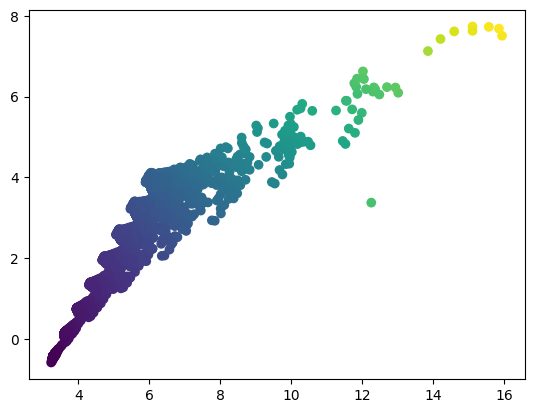

In [38]:
plt.scatter(x, c, c = y)

In [48]:
import os
import jax
import pandas as pd
class TestSpecimen :
    def __init__(self, data_dir: os.PathLike, mat_model: str):
        self.data_dir = data_dir
        self.mat_model = mat_model
        self.mat_model_path = os.path.join(data_dir, mat_model)
        self.loadsteps = os.listdir(self.mat_model_path)

    def __len__(self):

        return len(self.loadsteps)

    def __getitem__(self, loadstep) :
        files_path = os.path.join(self.mat_model_path, str(loadstep))
        files = os.listdir(files_path)
        data = dict()
        for f in files :
            if f.endswith(".csv") :
                data[f"{f.split(".")[0]}"] = pd.read_csv(files_path + "/" + f)
        output_nodes = data["output_nodes"]
        output_elements = data["output_elements"]

        coords = jnp.array(output_nodes[['x', 'y']].values)
        disp   = jnp.array(output_nodes[['ux', 'uy']].values)
        conn = jnp.array(output_elements[['node1', 'node2', 'node3']].values, dtype=int)
        def deformation_gradient_element(coords_elem, disp_elem):
            x1, y1 = coords_elem[0]
            x2, y2 = coords_elem[1]
            x3, y3 = coords_elem[2]

            # Jacobian of shape function derivatives
            J = jnp.array([
                [x2 - x1, x3 - x1],
                [y2 - y1, y3 - y1]
            ])

            # Area factor
            detJ = jnp.linalg.det(J)

            # Shape function derivatives in reference space
            dN_ref = jnp.array([
                [-1., -1.],
                [ 1.,  0.],
                [ 0.,  1.]
            ])

            # Convert to physical derivatives: dN/dx = inv(J)^T * dN_ref
            dNdx = jnp.transpose(jnp.linalg.solve(J, dN_ref))

            # Gradient of displacement
            gradu = disp_elem.T @ dNdx  # 2x3 @ 3x2 = 2x2

            # Deformation gradient
            F = jnp.eye(2) + gradu
            return F
        # Gather coords and disp for each element
        coords_elems = coords[conn]
        disp_elems   = disp[conn]

        # Vectorize the function
        f = jax.vmap(lambda ce, de: deformation_gradient_element(ce, de))(coords_elems, disp_elems)

        return dict(deformation_gradient = f)

In [49]:
data = TestSpecimen("dataset/benchmarks/test-specimen", "Isihara-GT")

In [50]:
data[10]

ValueError: inconsistent size for core dimension 'm': 3 vs 2 on vectorized function with excluded=frozenset() and signature='(m,m),(m,n)->(m,n)'